# Convergence and Frequency Analysis of Custom Loss Models

This notebook implements:
- **1.a**: Loss curve inspection
- **1.b**: Gradient norm analysis
- **1.c**: Hessian spectrum approximation
- **1.d**: 2D loss surface visualisation
- **2.d**: Frequency domain error analysis
- **3**: Patch vs Global comparisons

In [5]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.autograd import grad
from torch.autograd.functional import hessian
from scipy.fft import fft2, fftshift
from tqdm import tqdm


In [6]:
def find_checkpoint(root_dir, loss_name, epoch=None):
    """
    Find checkpoint for specified epoch or latest if not specified
    
    Args:
        root_dir (str): Path to root directory containing checkpoints
        epoch (int, optional): Specific epoch to load, if None loads latest
        
    Returns:
        str: Path to checkpoint file
        int: Epoch number found
    """
    # Get all files in directory
    files = os.listdir(root_dir)
    
    # Filter for checkpoint files and extract epoch numbers
    epoch_nums = []
    for f in files:
        if (f.endswith('.pth') or f.endswith('.pt')) and f.split("_")[0] == loss_name:
            try:
                # Extract epoch number from filename
                file_epoch = int(''.join(filter(str.isdigit, f)))
                epoch_nums.append((file_epoch, f))
            except ValueError:
                continue
    
    if not epoch_nums:
        raise FileNotFoundError(f"No checkpoint files found in {root_dir} for loss {loss_name}")
        
    if epoch is not None:
        # Try to find specified epoch
        matching = [x for x in epoch_nums if x[0] == epoch]
        if matching:
            return os.path.join(root_dir, matching[0][1]), matching[0][0]
        print(f"Warning: Epoch {epoch} not found, using latest instead")
        
    # Get file with highest epoch
    latest_epoch, latest_file = max(epoch_nums, key=lambda x: x[0])
    return os.path.join(root_dir, latest_file), latest_epoch

def load_checkpoint(root_dir, loss_name, epoch=None):
    """
    Load checkpoint for specified epoch or latest if not specified
    
    Args:
        root_dir (str): Path to checkpoints directory
        model: PyTorch model to load weights into
        epoch (int, optional): Specific epoch to load, if None loads latest
        
    Returns:
        model: Model with loaded weights
        int: Epoch number of loaded checkpoint
    """
    checkpoint_path, loaded_epoch = find_checkpoint(root_dir, loss_name, epoch)
    checkpoint = torch.load(checkpoint_path, weights_only=False)
    print(f"Loaded {loss_name} checkpoint from epoch {loaded_epoch}: {checkpoint_path}")
    return checkpoint

In [10]:
root_dir = "/Users/dp4018/Documents/WienerLoss/examples/wiener_exps"
_, epoch = find_checkpoint(root_dir, loss_name="MSELoss")

original, recon_wl, recon_pwl, recon_mswl, recon_mse = [], [], [], [], []
train_loss_wl, train_loss_pwl, train_loss_mswl, train_loss_mse = [], [], [], []

for i in range(1, epoch):
    ckpt = load_checkpoint(root_dir, "WienerLoss", epoch=i)
    original.append(ckpt["data"])
    recon_wl.append(ckpt["output"])
    train_loss_wl.append(ckpt["train_loss"])

    ckpt = load_checkpoint(root_dir, "PatchWienerLoss", epoch=i)
    recon_pwl.append(ckpt["output"])
    train_loss_pwl.append(ckpt["train_loss"])

    ckpt = load_checkpoint(root_dir, "MSWienerLoss", epoch=i)
    recon_mswl.append(ckpt["output"])
    train_loss_mswl.append(ckpt["train_loss"])

    ckpt = load_checkpoint(root_dir, "MSELoss", epoch=i)
    recon_mse.append(ckpt["output"])
    train_loss_mse.append(ckpt["train_loss"])

original = torch.cat(original, dim=0)
recon_wl = torch.cat(recon_wl, dim=0)
recon_pwl = torch.cat(recon_pwl, dim=0)
recon_mswl = torch.cat(recon_mswl, dim=0)
recon_mse = torch.cat(recon_mse, dim=0)


Loaded WienerLoss checkpoint from epoch 1: /Users/dp4018/Documents/WienerLoss/examples/wiener_exps/WienerLoss_epoch_1.pt
Loaded PatchWienerLoss checkpoint from epoch 1: /Users/dp4018/Documents/WienerLoss/examples/wiener_exps/PatchWienerLoss_epoch_1.pt
Loaded MSWienerLoss checkpoint from epoch 1: /Users/dp4018/Documents/WienerLoss/examples/wiener_exps/MSWienerLoss_epoch_1.pt
Loaded MSELoss checkpoint from epoch 1: /Users/dp4018/Documents/WienerLoss/examples/wiener_exps/MSELoss_epoch_1.pt
Loaded WienerLoss checkpoint from epoch 2: /Users/dp4018/Documents/WienerLoss/examples/wiener_exps/WienerLoss_epoch_2.pt
Loaded PatchWienerLoss checkpoint from epoch 2: /Users/dp4018/Documents/WienerLoss/examples/wiener_exps/PatchWienerLoss_epoch_2.pt
Loaded MSWienerLoss checkpoint from epoch 2: /Users/dp4018/Documents/WienerLoss/examples/wiener_exps/MSWienerLoss_epoch_2.pt
Loaded MSELoss checkpoint from epoch 2: /Users/dp4018/Documents/WienerLoss/examples/wiener_exps/MSELoss_epoch_2.pt
Loaded WienerLos

In [12]:
def plot_loss_curves(loss_dict):
    plt.figure(figsize=(10, 6))
    for label, losses in loss_dict.items():
        plt.plot(losses, label=label)
    plt.xlabel("Epoch")
    plt.ylabel("Training Loss")
    plt.title("Loss Curves")
    plt.legend()
    plt.grid(True)
    plt.show()

def compute_grad_norms(model, loss_fn, data_loader):
    grad_norms = []
    model.eval()
    for x, y in data_loader:
        model.zero_grad()
        out = model(x)
        loss = loss_fn(out, y)
        grads = grad(loss, model.parameters(), retain_graph=False, create_graph=False)
        norm = torch.sqrt(sum(torch.norm(g.detach())**2 for g in grads))
        grad_norms.append(norm.item())
    return grad_norms

def hessian_spectrum(model, loss_fn, x, y, topk=10):
    def loss_wrapper(params_vec):
        offset = 0
        for p in model.parameters():
            numel = p.numel()
            p.data = params_vec[offset:offset + numel].view(p.shape)
            offset += numel
        out = model(x)
        return loss_fn(out, y)

    params = torch.cat([p.data.view(-1) for p in model.parameters()])
    hess = hessian(loss_wrapper, params)
    hess_np = hess.detach().cpu().numpy()
    eigvals = np.linalg.eigvalsh(hess_np)
    return eigvals[-topk:]

def loss_surface_2d(model, loss_fn, x, y, direction1, direction2, alpha_range):
    base_params = torch.cat([p.data.view(-1) for p in model.parameters()])
    losses = np.zeros((len(alpha_range), len(alpha_range)))
    for i, a1 in enumerate(alpha_range):
        for j, a2 in enumerate(alpha_range):
            new_params = base_params + a1 * direction1 + a2 * direction2
            offset = 0
            for p in model.parameters():
                numel = p.numel()
                p.data = new_params[offset:offset + numel].view(p.shape)
                offset += numel
            with torch.no_grad():
                out = model(x)
                loss_val = loss_fn(out, y).item()
            losses[i, j] = loss_val
    return losses

def fft_error(original, recon):
    orig_fft = np.abs(fftshift(fft2(original)))
    recon_fft = np.abs(fftshift(fft2(recon)))
    return orig_fft - recon_fft

def patchwise_fft_error(original, recon, patch_size):
    h, w = original.shape
    ph, pw = patch_size
    errors = []
    for i in range(0, h, ph):
        for j in range(0, w, pw):
            o_patch = original[i:i+ph, j:j+pw]
            r_patch = recon[i:i+ph, j:j+pw]
            if o_patch.shape == (ph, pw):
                error = fft_error(o_patch, r_patch)
                errors.append(error)
    return errors

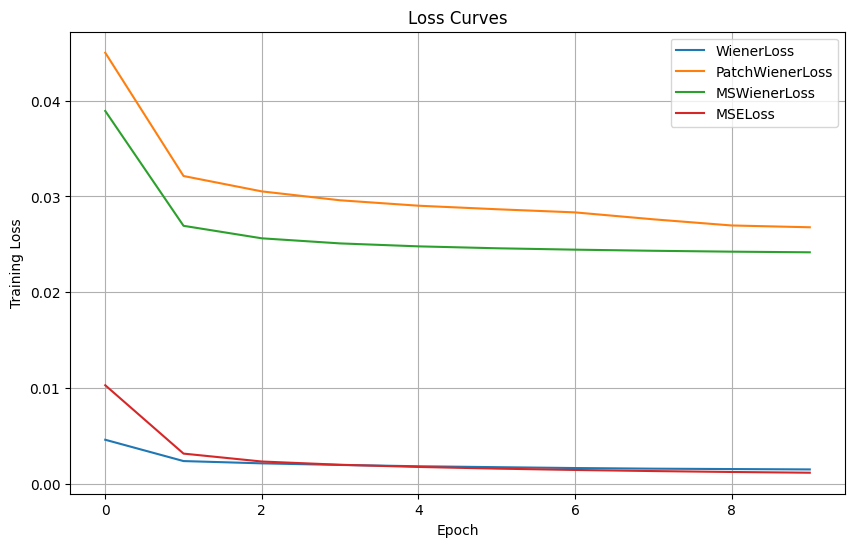

In [13]:
train_loss_dict = {
    "WienerLoss": train_loss_wl,
    "PatchWienerLoss": train_loss_pwl,
    "MSWienerLoss": train_loss_mswl,
    "MSELoss": train_loss_mse
}
plot_loss_curves(train_loss_dict)